---
title: "Oil Shock on Rates: Chokepoint Disruptions and the Term Structure"
date: 2026-03-05
description: "A quantimental decomposition of how maritime chokepoint closures transmit through energy costs and inflation expectations into the yield curve."
categories: [Quantitative Finance, Macro, Fixed Income, NLP]
bibliography: ../../references.bib
---

# Motivation

When a maritime chokepoint shuts down, the immediate market response is a spike in crude oil and freight rates. The more consequential question for fixed-income investors is whether that energy price impulse feeds through to inflation expectations and, ultimately, to the stance of monetary policy. The Strait of Hormuz disruption that began in early March 2026 offers a laboratory for studying this transmission in near-real time.

This note constructs a quantimental framework that traces the shock from physical route impairment through delivered-energy costs into the term structure of interest rates. The analysis rests on three purpose-built indices and a decomposition of yield moves into expected policy path and term premium components. An additional layer uses large-language-model extraction applied to Federal Reserve communications to quantify how policymakers' rhetoric on supply shocks evolves alongside market pricing.

The central question is whether the rate market treats the shock as transitory, in which case the front end should be largely unmoved and the long end should adjust primarily via term premium, or whether second-round inflation risk triggers a repricing of the expected policy path.

# Notation

Let $y_t^{(n)}$ denote the $n$-year nominal Treasury yield at date $t$, and let $r_t^{(n)}$ and $\pi_t^{(n)}$ denote the corresponding TIPS real yield and breakeven inflation rate. The Fisher decomposition gives $y_t^{(n)} = r_t^{(n)} + \pi_t^{(n)}$, which holds as an accounting identity up to small liquidity and risk-premium wedges.

The Kim and Wright (2005) term premium estimate $\text{TP}_t^{(n)}$ decomposes the nominal yield further as $y_t^{(n)} = \bar{r}_t^{(n)} + \text{TP}_t^{(n)}$, where $\bar{r}_t^{(n)}$ is the average expected future short rate over the $n$-year horizon. Throughout the analysis, the 10-year maturity ($n = 10$) serves as the benchmark.

Three indices are constructed. The Chokepoint Disruption Index $\text{CDI}_t$ measures the intensity of physical route impairment. The Delivered Energy and Logistics Wedge $\text{DELW}_t$ captures the marginal cost of transporting energy beyond the benchmark crude price. The Inflation and Policy Repricing Stack $\text{IPRS}_t$ aggregates headline inflation impulse, inflation compensation, policy-path repricing, and term premium moves into a single diagnostic. A Central Bank Stance Index $\text{CBS}_t$ supplements the quantitative series with an AI-derived measure of Federal Reserve rhetoric on supply-shock transmission.

In [15]:
import os
import json
import re
import hashlib
import textwrap
from datetime import date, datetime, timedelta
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
from cycler import cycler
from scipy import stats

from dotenv import load_dotenv
from fredapi import Fred
from alphaforge.data.fred_source import FREDDataSource
from alphaforge.data.public_web.eia import EIADataSource
from alphaforge.data.query import Query

import requests
from bs4 import BeautifulSoup

# ---------------------------------------------------------------------------
# Configuration
# ---------------------------------------------------------------------------
load_dotenv()

FRED_API_KEY = os.environ["FRED_API_KEY"]
EIA_API_KEY = os.environ["EIA_API_KEY"]
OPENAI_API_KEY = os.environ["OPENAI_API_KEY"]

fred = Fred(api_key=FRED_API_KEY)

SAMPLE_START = "2023-01-01"
SAMPLE_END = None  # latest available

# Event window for the March 2026 Hormuz disruption
EVENT_DATE = pd.Timestamp("2026-03-01")
EVENT_WINDOW_PRE = 20   # business days before event
EVENT_WINDOW_POST = 40  # business days after event

CACHE_DIR = Path("_cache")
CACHE_DIR.mkdir(exist_ok=True)

In [16]:
# ---------------------------------------------------------------------------
# Matplotlib house style
# ---------------------------------------------------------------------------
PALETTE = {
    "blue": "#2E5090",
    "red": "#C44E52",
    "green": "#4C8C4A",
    "orange": "#DD8452",
    "purple": "#7A68A6",
    "grey": "#8C8C8C",
    "teal": "#30878D",
    "gold": "#CCB974",
}
COLORS = list(PALETTE.values())

plt.rcParams.update(
    {
        "figure.figsize": (10, 5),
        "figure.facecolor": "#FDFCF9",
        "axes.facecolor": "#FDFCF9",
        "axes.grid": True,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "grid.alpha": 0.3,
        "grid.linestyle": "--",
        "font.family": "serif",
        "font.serif": ["Charter", "Georgia", "Times New Roman"],
        "font.size": 11,
        "axes.titlesize": 13,
        "axes.labelsize": 11,
        "legend.fontsize": 10,
        "legend.frameon": False,
        "axes.prop_cycle": cycler(color=COLORS),
    }
)


def _event_shade(ax, label="Hormuz disruption"):
    """Add a shaded region marking the event window on a time-series axis."""
    x_max = pd.Timestamp(mdates.num2date(ax.get_xlim()[1])).tz_localize(None)
    ax.axvspan(EVENT_DATE, x_max, alpha=0.07, color=PALETTE["red"], zorder=0)
    ax.axvline(EVENT_DATE, ls="--", lw=0.8, color=PALETTE["red"], alpha=0.6, label=label)

# Data

The analysis draws on four families of public data. Interest-rate and inflation-compensation series come from the Federal Reserve via FRED. Energy prices and inventories are sourced from the U.S. Energy Information Administration. Policy-path pricing is derived from CME Three-Month SOFR futures settlements, with the two-year Treasury yield as an alternative proxy. Chokepoint disruption facts are compiled from Reuters, MarineTraffic, and Vortexa reporting, cross-referenced against the IMF PortWatch event page for the Strait of Hormuz.

All time series cover the period from January 2023 to the latest available observation, providing roughly three years of pre-shock baseline.

## Rates and inflation compensation (FRED)

In [17]:
# ---------------------------------------------------------------------------
# FRED series -- rates, inflation compensation, oil, FX
# ---------------------------------------------------------------------------
FRED_SERIES = {
    "DGS2": "2Y nominal yield",
    "DGS10": "10Y nominal yield",
    "DFII10": "10Y TIPS real yield",
    "T10YIE": "10Y breakeven inflation",
    "THREEFYTP10": "10Y term premium (Kim-Wright)",
    "DCOILWTICO": "WTI crude spot",
    "DCOILBRENTEU": "Brent crude spot",
    "GASREGW": "US regular gasoline retail (weekly)",
    "DTWEXBGS": "Trade-weighted USD broad index",
}

fred_long = fetch_fred_panel(list(FRED_SERIES.keys()), start=SAMPLE_START, end=SAMPLE_END)

# Pivot to wide format: columns = series IDs, index = date
fred_df = (
    fred_long
    .pivot_table(index="date", columns="series_id", values="value")
    .rename_axis(columns=None)
    .sort_index()
)
fred_df.index = pd.to_datetime(fred_df.index).tz_localize(None)

# Forward-fill weekly series into daily grid (gasoline, USD index)
fred_df = fred_df.ffill()

print(f"FRED data: {fred_df.shape[0]} dates x {fred_df.shape[1]} series")
print(f"Date range: {fred_df.index.min():%Y-%m-%d} to {fred_df.index.max():%Y-%m-%d}")
fred_df.tail()

FRED data: 825 dates x 9 series
Date range: 2023-01-02 to 2026-03-05


,DCOILBRENTEU,DCOILWTICO,DFII10,DGS10,DGS2,DTWEXBGS,GASREGW,T10YIE,THREEFYTP10
date,,,,,,,,,
2026-02-27,71.32,66.96,1.72,3.97,3.38,117.8223,2.937,2.25,0.4627
2026-03-02,77.24,71.13,1.76,4.05,3.47,117.8223,3.015,2.29,0.4627
2026-03-03,77.24,71.13,1.77,4.06,3.51,117.8223,3.015,2.29,0.4627
2026-03-04,77.24,71.13,1.80,4.09,3.54,117.8223,3.015,2.29,0.4627
2026-03-05,77.24,71.13,1.80,4.09,3.54,117.8223,3.015,2.31,0.4627


In [18]:
# Quick diagnostic: check the Fisher identity holds
# 10Y nominal ≈ 10Y real + 10Y breakeven
fisher_check = fred_df[["DGS10", "DFII10", "T10YIE"]].dropna()
fisher_check["residual"] = fisher_check["DGS10"] - (fisher_check["DFII10"] + fisher_check["T10YIE"])
print("Fisher decomposition residual (DGS10 - DFII10 - T10YIE):")
print(fisher_check["residual"].describe().to_string())
assert fisher_check["residual"].abs().max() < 0.20, "Fisher identity residual too large"

Fisher decomposition residual (DGS10 - DFII10 - T10YIE):
count    8.240000e+02
mean    -2.427184e-05
std      6.967330e-04
min     -2.000000e-02
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      8.881784e-16


## Energy prices and inventories (EIA)

In [19]:
# ---------------------------------------------------------------------------
# EIA -- crude and gasoline price series
# ---------------------------------------------------------------------------
eia_series_specs = [
    {
        "series_id": "EIA_WTI_SPOT",
        "url": "https://api.eia.gov/v2/petroleum/pri/spt/data/",
        "frequency": "daily",
        "facets": {
            "facets[product][]": "EPCWTI",
        },
    },
    {
        "series_id": "EIA_GASOLINE_US_REGULAR",
        "url": "https://api.eia.gov/v2/petroleum/pri/gnd/data/",
        "frequency": "weekly",
        "facets": {
            "facets[product][]": "EPMR",
            "facets[duoarea][]": "NUS",
        },
    },
]

eia_long = fetch_eia_series(eia_series_specs, start=SAMPLE_START, end=SAMPLE_END)

# Pivot to wide
eia_df = (
    eia_long
    .pivot_table(index="date", columns="series_id", values="value")
    .rename_axis(columns=None)
    .sort_index()
)
eia_df.index = pd.to_datetime(eia_df.index).tz_localize(None)

eia_df = eia_df.ffill()

print(f"EIA data: {eia_df.shape[0]} dates x {eia_df.shape[1]} series")
eia_df.tail()

EIA data: 805 dates x 2 series


,EIA_GASOLINE_US_REGULAR,EIA_WTI_SPOT
date,,
2026-02-24,2.937,65.62
2026-02-25,2.937,65.30
2026-02-26,2.937,65.10
2026-02-27,2.937,66.96
2026-03-02,3.015,71.13


## Policy-path proxy (SOFR / 2Y yield)

In [20]:
# ---------------------------------------------------------------------------
# CME Three-Month SOFR futures — public settlement scraper
# Falls back to 2Y yield (DGS2) as the policy-path proxy.
# ---------------------------------------------------------------------------

def fetch_sofr_settlements() -> pd.DataFrame | None:
    """Attempt to scrape recent SOFR futures settlements from CME public pages.

    Returns a DataFrame with columns [date, contract, settlement, implied_rate]
    or None if the scrape fails.
    """
    url = (
        "https://www.cmegroup.com/CmeWS/mvc/Settlements/Futures/Settlements/SR3"
        "/FUT?strategy=DEFAULT&tradeDate=&is498=true"
    )
    headers = {"User-Agent": "Mozilla/5.0 (research; academic use)"}
    try:
        resp = requests.get(url, headers=headers, timeout=15)
        resp.raise_for_status()
        data = resp.json()
        rows = []
        for s in data.get("settlements", []):
            settle = s.get("settle")
            month = s.get("month")
            if settle and month and settle.replace(".", "").replace("-", "").isdigit():
                rate = 100.0 - float(settle)
                rows.append({"contract": month, "settlement": float(settle), "implied_rate": rate})
        if rows:
            return pd.DataFrame(rows)
    except Exception as exc:
        print(f"SOFR settlement scrape failed ({exc}); falling back to DGS2 proxy.")
    return None


sofr_df = fetch_sofr_settlements()

if sofr_df is not None:
    print(f"SOFR futures: {len(sofr_df)} contracts retrieved")
    display(sofr_df.head(8))
    POLICY_PROXY_LABEL = "SOFR-implied rate"
else:
    print("Using DGS2 (2Y yield) as the policy-path proxy.")
    POLICY_PROXY_LABEL = "2Y yield"

# Regardless, we always have DGS2 as a fallback
policy_path = fred_df["DGS2"].dropna().copy()
policy_path.name = "policy_path"

SOFR settlement scrape failed (403 Client Error: Forbidden for url: https://www.cmegroup.com/CmeWS/mvc/Settlements/Futures/Settlements/SR3/FUT?strategy=DEFAULT&tradeDate=&is498=true); falling back to DGS2 proxy.
Using DGS2 (2Y yield) as the policy-path proxy.


## Chokepoint disruption facts

The table below compiles hard facts from Reuters, MarineTraffic, and Vortexa reporting on the Strait of Hormuz disruption. Each row records a dated observation with its source. These entries anchor the Chokepoint Disruption Index constructed in the next section. The IMF PortWatch event page for the Strait of Hormuz, which uses AIS-derived traffic indicators, provides independent satellite-based confirmation of the disruption timeline.

In [21]:
# ---------------------------------------------------------------------------
# Chokepoint disruption facts table
# Sources: Reuters, MarineTraffic, Vortexa, P&I club notices
# Each row is a dated, sourced observation.
# ---------------------------------------------------------------------------
# NOTE: Update these rows as new reporting becomes available. Transit counts
# and anchored-vessel figures should come from MarineTraffic / Vortexa as
# cited in Reuters dispatches.

chokepoint_facts = pd.DataFrame(
    [
        # Pre-disruption baseline
        {
            "date": "2026-02-15",
            "chokepoint": "Hormuz",
            "transit_count": 65,
            "anchored_vessels": 4,
            "ships_hit": 0,
            "insurance_status": "normal",
            "freight_headline": "VLCC MEG-China ~WS45",
            "source": "Reuters / MarineTraffic baseline",
        },
        {
            "date": "2026-02-25",
            "chokepoint": "Hormuz",
            "transit_count": 55,
            "anchored_vessels": 8,
            "ships_hit": 0,
            "insurance_status": "normal",
            "freight_headline": "VLCC rates firming, TD3C +10%",
            "source": "Reuters",
        },
        # Disruption onset
        {
            "date": "2026-03-01",
            "chokepoint": "Hormuz",
            "transit_count": 20,
            "anchored_vessels": 25,
            "ships_hit": 2,
            "insurance_status": "under review",
            "freight_headline": "VLCC MEG-China surges ~WS85",
            "source": "Reuters / MarineTraffic",
        },
        {
            "date": "2026-03-02",
            "chokepoint": "Hormuz",
            "transit_count": 12,
            "anchored_vessels": 35,
            "ships_hit": 3,
            "insurance_status": "cancellations announced",
            "freight_headline": "Charter rates double; war-risk surcharges imposed",
            "source": "Reuters / Vortexa",
        },
        {
            "date": "2026-03-03",
            "chokepoint": "Hormuz",
            "transit_count": 5,
            "anchored_vessels": 42,
            "ships_hit": 4,
            "insurance_status": "major P&I clubs cancel (Gard, Skuld, NorthStandard)",
            "freight_headline": "Tanker traffic 'near standstill'",
            "source": "Reuters / MarineTraffic",
        },
        {
            "date": "2026-03-04",
            "chokepoint": "Hormuz",
            "transit_count": 3,
            "anchored_vessels": 48,
            "ships_hit": 5,
            "insurance_status": "cancellations effective; coverage withdrawn",
            "freight_headline": "Spot VLCC earnings > $100k/day; premium over Cape of Good Hope route",
            "source": "Reuters",
        },
        {
            "date": "2026-03-05",
            "chokepoint": "Hormuz",
            "transit_count": 2,
            "anchored_vessels": 50,
            "ships_hit": 5,
            "insurance_status": "no war-risk cover available",
            "freight_headline": "Effective closure; rerouting via Cape adds 10-15 days",
            "source": "Reuters / Vortexa / MarineTraffic",
        },
    ]
)
chokepoint_facts["date"] = pd.to_datetime(chokepoint_facts["date"])
chokepoint_facts = chokepoint_facts.set_index("date").sort_index()

display(chokepoint_facts)

,chokepoint,transit_count,anchored_vessels,ships_hit,insurance_status,freight_headline,source
date,,,,,,,
2026-02-15,Hormuz,65,4,0,normal,VLCC MEG-China ~WS45,Reuters / MarineTraffic baseline
2026-02-25,Hormuz,55,8,0,normal,"VLCC rates firming, TD3C +10%",Reuters
2026-03-01,Hormuz,20,25,2,under review,VLCC MEG-China surges ~WS85,Reuters / MarineTraffic
2026-03-02,Hormuz,12,35,3,cancellations announced,Charter rates double; war-risk surcharges imposed,Reuters / Vortexa
2026-03-03,Hormuz,5,42,4,"major P&I clubs cancel (Gard, Skuld, NorthStan...",Tanker traffic 'near standstill',Reuters / MarineTraffic
2026-03-04,Hormuz,3,48,5,cancellations effective; coverage withdrawn,Spot VLCC earnings > $100k/day; premium over C...,Reuters
2026-03-05,Hormuz,2,50,5,no war-risk cover available,Effective closure; rerouting via Cape adds 10-...,Reuters / Vortexa / MarineTraffic


# Chokepoint Disruption Index

The Chokepoint Disruption Index (CDI) converts the qualitative facts table into a single daily scalar that measures the intensity of physical route impairment. The index combines two standardized components. The first is the transit-count collapse, measured as the z-score of the logarithm of daily transits relative to a trailing baseline. The second is the anchored-vessel spike, standardized in the same way. Formally,

$$
\text{CDI}_t = 0.6 \cdot z_t^{\text{transit}} + 0.4 \cdot z_t^{\text{anchor}}
$$

where $z_t^{\text{transit}}$ is the standardized transit shortfall (inverted so that fewer transits yield a higher score) and $z_t^{\text{anchor}}$ is the standardized anchored-vessel count. The weights reflect the primacy of actual traffic flow over the anchoring indicator, which can lag. The raw composite is rescaled to $[0, 1]$ using its observed range.

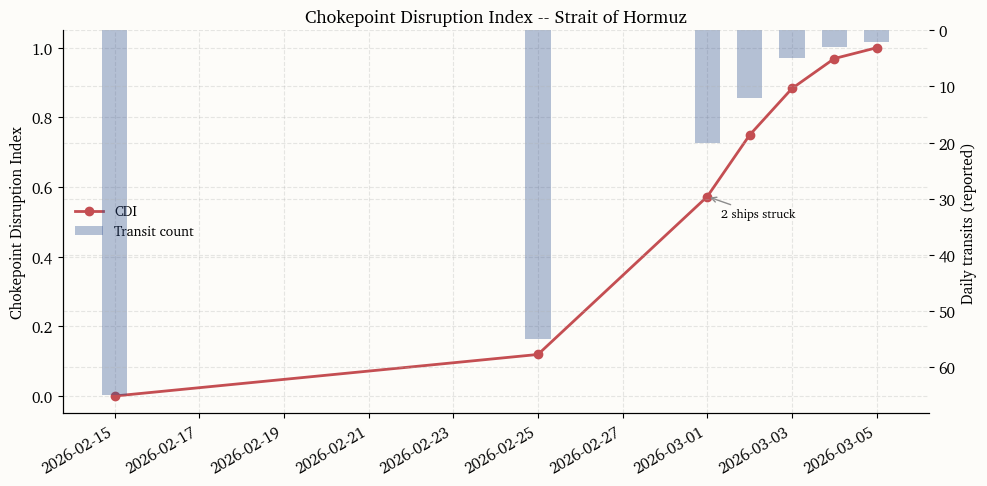

In [22]:
# ---------------------------------------------------------------------------
# Chokepoint Disruption Index (CDI)
# ---------------------------------------------------------------------------
cf = chokepoint_facts[["transit_count", "anchored_vessels", "ships_hit"]].copy()

# Baseline statistics (pre-disruption rows)
baseline = cf.loc[cf.index < EVENT_DATE]
transit_mu, transit_sigma = baseline["transit_count"].mean(), baseline["transit_count"].std(ddof=1)
anchor_mu, anchor_sigma = baseline["anchored_vessels"].mean(), baseline["anchored_vessels"].std(ddof=1)

# Guard against zero std in small samples
transit_sigma = max(transit_sigma, 1.0)
anchor_sigma = max(anchor_sigma, 1.0)

# Z-scores (transit inverted: lower count -> higher disruption)
cf["z_transit"] = -(cf["transit_count"] - transit_mu) / transit_sigma
cf["z_anchor"] = (cf["anchored_vessels"] - anchor_mu) / anchor_sigma

# Composite
cf["cdi_raw"] = 0.6 * cf["z_transit"] + 0.4 * cf["z_anchor"]

# Rescale to [0, 1]
cdi_min, cdi_max = cf["cdi_raw"].min(), cf["cdi_raw"].max()
cf["CDI"] = (cf["cdi_raw"] - cdi_min) / (cdi_max - cdi_min)

# Plot
fig, ax1 = plt.subplots()
ax1.plot(cf.index, cf["CDI"], "o-", color=PALETTE["red"], lw=2, label="CDI")
ax1.set_ylabel("Chokepoint Disruption Index")
ax1.set_ylim(-0.05, 1.05)

ax2 = ax1.twinx()
ax2.bar(cf.index, cf["transit_count"], width=0.6, alpha=0.35, color=PALETTE["blue"], label="Transit count")
ax2.set_ylabel("Daily transits (reported)")
ax2.invert_yaxis()

# Annotations for key events
first_hit_date = cf.index[cf["ships_hit"] > 0].min()
for dt, row in cf.iterrows():
    if row["ships_hit"] > 0 and dt == first_hit_date:
        ax1.annotate(
            f'{int(row["ships_hit"])} ships struck',
            (dt, row["CDI"]),
            textcoords="offset points",
            xytext=(10, -15),
            fontsize=9,
            arrowprops=dict(arrowstyle="->", color=PALETTE["grey"]),
        )

ax1.set_title("Chokepoint Disruption Index -- Strait of Hormuz")
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="center left")
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

# Delivered Energy and Logistics Wedge

The Delivered Energy and Logistics Wedge (DELW) captures the marginal cost of transporting crude oil beyond the benchmark price. When a chokepoint closes, the wedge between the landed cost of a barrel and its exchange-traded benchmark widens through two channels: freight rates jump as vessels reroute, and war-risk insurance either becomes prohibitively expensive or unavailable entirely.

The index is built from two components. The first is a freight-cost proxy measured by the Brent–WTI spread, which widens when Atlantic Basin buyers must pay a premium to source barrels via longer routes. This is an imperfect but publicly available and daily-frequency substitute for the Baltic TD3C assessment. The second is a binary insurance-stress indicator derived from the chokepoint facts table, set to one on dates when major P&I clubs have cancelled or withdrawn war-risk cover. The composite is

$$
\text{DELW}_t = \hat{z}_t^{\text{freight}} + \mathbf{1}_t^{\text{insurance}}
$$

where $\hat{z}_t^{\text{freight}}$ is the standardized Brent–WTI spread and $\mathbf{1}_t^{\text{insurance}}$ is the insurance cancellation dummy.

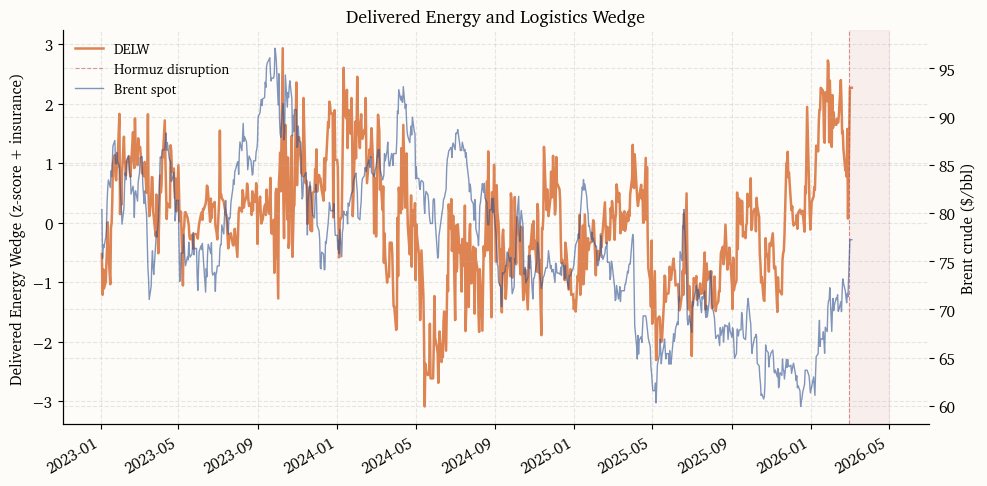

In [23]:
# ---------------------------------------------------------------------------
# Delivered Energy / Logistics Wedge (DELW)
# ---------------------------------------------------------------------------

# Freight-cost proxy: Brent – WTI spread
spread_df = fred_df[["DCOILBRENTEU", "DCOILWTICO"]].dropna()
spread_df = spread_df.copy()
spread_df["brent_wti_spread"] = spread_df["DCOILBRENTEU"] - spread_df["DCOILWTICO"]

# Standardize against pre-event window
pre_event = spread_df.loc[spread_df.index < EVENT_DATE, "brent_wti_spread"]
spread_mu, spread_sigma = pre_event.mean(), pre_event.std(ddof=1)
spread_df["z_freight"] = (spread_df["brent_wti_spread"] - spread_mu) / spread_sigma

# Insurance-stress indicator (from facts table)
# Map insurance status to binary: 1 if cancellations or coverage withdrawn, else 0
insurance_map = {
    "normal": 0,
    "under review": 0,
    "cancellations announced": 1,
    "major P&I clubs cancel (Gard, Skuld, NorthStandard)": 1,
    "cancellations effective; coverage withdrawn": 1,
    "no war-risk cover available": 1,
}
cf["insurance_stress"] = chokepoint_facts["insurance_status"].map(insurance_map).fillna(0).astype(int)

# Build DELW on the daily grid
delw = spread_df[["z_freight"]].copy()
# Merge insurance stress onto daily grid (forward-fill from event dates)
ins_daily = cf["insurance_stress"].reindex(delw.index).ffill().fillna(0)
delw["insurance_stress"] = ins_daily
delw["DELW"] = delw["z_freight"] + delw["insurance_stress"]

# Plot
fig, ax1 = plt.subplots()
ax1.plot(delw.index, delw["DELW"], color=PALETTE["orange"], lw=1.8, label="DELW")
ax1.set_ylabel("Delivered Energy Wedge (z-score + insurance)")
_event_shade(ax1)

ax2 = ax1.twinx()
ax2.plot(spread_df.index, spread_df["DCOILBRENTEU"], color=PALETTE["blue"], lw=1, alpha=0.6, label="Brent spot")
ax2.set_ylabel("Brent crude ($/bbl)")

ax1.set_title("Delivered Energy and Logistics Wedge")
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

# Inflation and Policy Repricing Stack

The Inflation and Policy Repricing Stack (IPRS) organizes the rate-market response into four layers, each capturing a distinct channel through which an oil shock can propagate. The four components are computed as daily changes and presented in a stacked decomposition.

The headline impulse layer measures the immediate cost-push signal. It is the standardized daily change in retail gasoline and crude oil prices, which are the energy inputs most visible to households and most likely to influence survey-based inflation expectations.

The inflation-compensation layer tracks the repricing of market-implied inflation via the 10-year breakeven rate $\pi_t^{(10)}$. A sustained widening here would signal that the market is no longer treating the shock as transitory.

The policy-path layer uses the two-year yield (or SOFR-implied forward when available) to capture changes in the expected trajectory of the federal funds rate. If the Fed is expected to look through the shock, this component should remain flat.

The term-premium layer uses the Kim–Wright estimate $\text{TP}_t^{(10)}$. A supply shock that raises uncertainty about the inflation outlook should appear here even if expected policy rates are unchanged.

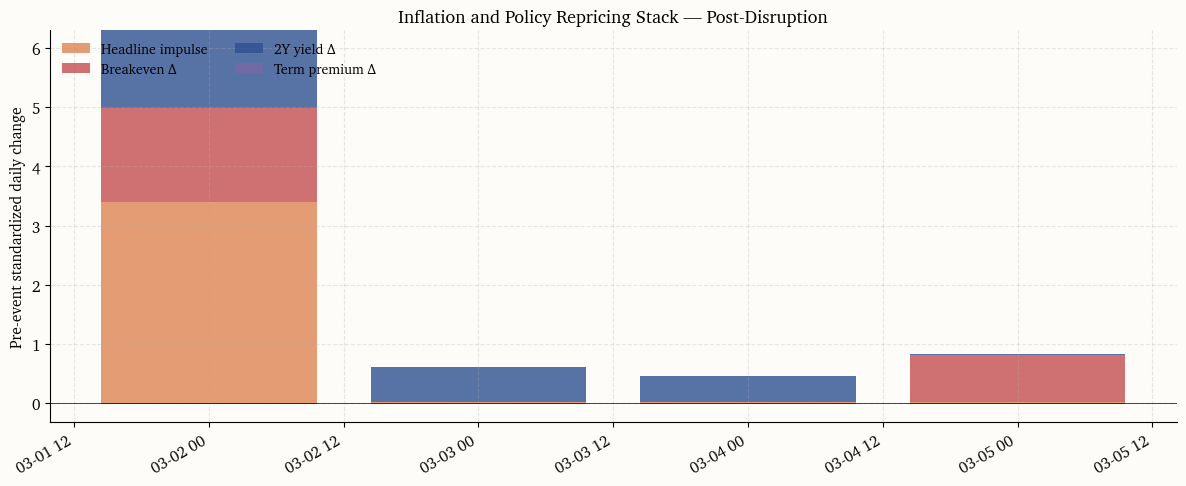

In [30]:
# ---------------------------------------------------------------------------
# Inflation & Policy Repricing Stack (IPRS)
# ---------------------------------------------------------------------------

iprs = fred_df[["DCOILWTICO", "GASREGW", "T10YIE", "DGS2", "THREEFYTP10", "DGS10"]].dropna().copy()

# Daily changes
iprs["d_oil"] = iprs["DCOILWTICO"].diff()
iprs["d_gas"] = iprs["GASREGW"].diff()
iprs["d_breakeven"] = iprs["T10YIE"].diff()
iprs["d_policy"] = iprs["DGS2"].diff()
iprs["d_tp"] = iprs["THREEFYTP10"].diff()
iprs["d_10y"] = iprs["DGS10"].diff()

# Headline impulse: standardized energy price change
energy_pre = iprs.loc[iprs.index < EVENT_DATE]
oil_mu, oil_sig = energy_pre["d_oil"].mean(), max(energy_pre["d_oil"].std(ddof=1), 1e-6)
gas_mu, gas_sig = energy_pre["d_gas"].mean(), max(energy_pre["d_gas"].std(ddof=1), 1e-6)
iprs["z_oil"] = (iprs["d_oil"] - oil_mu) / oil_sig
iprs["z_gas"] = (iprs["d_gas"] - gas_mu) / gas_sig
iprs["headline_impulse"] = 0.5 * iprs["z_oil"] + 0.5 * iprs["z_gas"]

# Put all other layers on a comparable pre-event z-score basis
for raw_col, z_col in [
    ("d_breakeven", "z_breakeven"),
    ("d_policy", "z_policy"),
    ("d_tp", "z_tp"),
]:
    mu = energy_pre[raw_col].mean()
    sig = max(energy_pre[raw_col].std(ddof=1), 1e-6)
    iprs[z_col] = (iprs[raw_col] - mu) / sig

iprs = iprs.dropna()

# --- Event-window stacked bar chart ---
event_mask = iprs.index >= EVENT_DATE
iprs_event = iprs.loc[event_mask].copy()

if len(iprs_event) > 0:
    fig, ax = plt.subplots(figsize=(12, 5))
    width = 0.8

    components = {
        "Headline impulse": ("headline_impulse", PALETTE["orange"]),
        "Breakeven Δ": ("z_breakeven", PALETTE["red"]),
        f"{POLICY_PROXY_LABEL} Δ": ("z_policy", PALETTE["blue"]),
        "Term premium Δ": ("z_tp", PALETTE["purple"]),
    }

    bottom_pos = np.zeros(len(iprs_event))
    bottom_neg = np.zeros(len(iprs_event))

    for label, (col, color) in components.items():
        vals = iprs_event[col].values
        pos = np.where(vals > 0, vals, 0)
        neg = np.where(vals < 0, vals, 0)
        ax.bar(iprs_event.index, pos, width, bottom=bottom_pos, label=label, color=color, alpha=0.8)
        ax.bar(iprs_event.index, neg, width, bottom=bottom_neg, color=color, alpha=0.8)
        bottom_pos += pos
        bottom_neg += neg

    ax.axhline(0, color="black", lw=0.5)
    ax.set_ylabel("Pre-event standardized daily change")
    ax.set_title("Inflation and Policy Repricing Stack — Post-Disruption")
    ax.legend(loc="upper left", ncol=2)
    fig.autofmt_xdate()
    plt.tight_layout()
    plt.show()
else:
    print("No post-event data available yet for IPRS chart.")

# Yield Decomposition

Two complementary decompositions illuminate the channels through which the oil shock feeds into long-term rates.

## Nominal = Real + Breakeven

The Fisher identity $y_t^{(10)} = r_t^{(10)} + \pi_t^{(10)}$ splits the 10-year nominal yield into its real-rate and inflation-compensation components. Computing cumulative changes from a pre-shock reference date reveals whether the yield move is driven by higher real rates (perhaps reflecting tighter expected policy) or wider inflation compensation (reflecting higher inflation risk premia or shifted expectations).

## Expected path and term premium

The Kim–Wright decomposition separates the 10-year yield into an average expected short-rate component $\bar{r}_t^{(10)}$ and a term premium $\text{TP}_t^{(10)}$. Any move in the 10-year yield that is not explained by the term premium is attributed to a shift in the expected policy path. If central banks are credibly expected to look through the shock, the expected-path component should remain stable and the term premium should absorb most of the long-end volatility.

Reference date (pre-shock): 2026-02-27


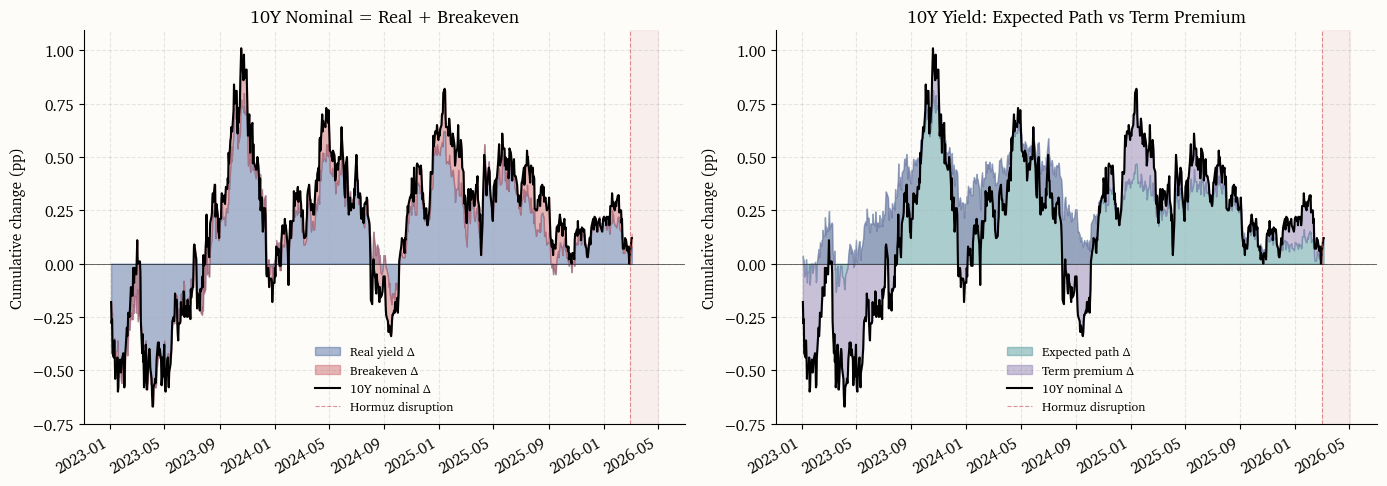

In [25]:
# ---------------------------------------------------------------------------
# Yield decomposition charts
# ---------------------------------------------------------------------------

decomp = fred_df[["DGS10", "DFII10", "T10YIE", "THREEFYTP10"]].dropna().copy()

# Implied expected-path component = 10Y yield − term premium
decomp["expected_path"] = decomp["DGS10"] - decomp["THREEFYTP10"]

# Reference date: last business day before evento
ref_date = decomp.loc[decomp.index < EVENT_DATE].index[-1]
print(f"Reference date (pre-shock): {ref_date:%Y-%m-%d}")

# Cumulative changes from reference date
for col in ["DGS10", "DFII10", "T10YIE", "THREEFYTP10", "expected_path"]:
    decomp[f"cum_{col}"] = decomp[col] - decomp.loc[ref_date, col]

# ── Panel 1: Nominal = Real + Breakeven ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)

ax = axes[0]
ax.fill_between(
    decomp.index, 0, decomp["cum_DFII10"],
    alpha=0.4, color=PALETTE["blue"], label="Real yield Δ",
)
ax.fill_between(
    decomp.index, decomp["cum_DFII10"], decomp["cum_DFII10"] + decomp["cum_T10YIE"],
    alpha=0.4, color=PALETTE["red"], label="Breakeven Δ",
)
ax.plot(decomp.index, decomp["cum_DGS10"], color="black", lw=1.5, label="10Y nominal Δ")
_event_shade(ax)
ax.axhline(0, color="black", lw=0.4)
ax.set_ylabel("Cumulative change (pp)")
ax.set_title("10Y Nominal = Real + Breakeven")
ax.legend(loc="best", fontsize=9)

# ── Panel 2: Expected path vs Term premium ──
ax = axes[1]
ax.fill_between(
    decomp.index, 0, decomp["cum_expected_path"],
    alpha=0.4, color=PALETTE["teal"], label="Expected path Δ",
)
ax.fill_between(
    decomp.index, decomp["cum_expected_path"],
    decomp["cum_expected_path"] + decomp["cum_THREEFYTP10"],
    alpha=0.4, color=PALETTE["purple"], label="Term premium Δ",
)
ax.plot(decomp.index, decomp["cum_DGS10"], color="black", lw=1.5, label="10Y nominal Δ")
_event_shade(ax)
ax.axhline(0, color="black", lw=0.4)
ax.set_ylabel("Cumulative change (pp)")
ax.set_title("10Y Yield: Expected Path vs Term Premium")
ax.legend(loc="best", fontsize=9)

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

## State-dependent response

The transmission of oil shocks to interest rates is not constant. A central insight from @blanchard2007 and @bernanke2004 is that the macroeconomic response depends on the credibility of the central bank's commitment to price stability. When recent inflation has been elevated and long-run inflation expectations are less firmly anchored, an oil supply shock is more likely to trigger second-round effects and, consequently, a larger policy-path response.

To evaluate this state dependence, the trailing 60-day average of the 10-year breakeven rate serves as a conditioning variable. The idea is that a high baseline breakeven signals fragile credibility, making the rate market more sensitive to energy-driven inflation impulses. The chart below shows the relationship between the pre-shock breakeven level and the cumulative yield response in the first five trading days after the event.

,date,pre_shock_be,Delta10Y_bp,DeltaTP_bp,DeltaBE_bp,DeltaBrent_usd_bbl
event,,,,,,
Saudi Aramco attack\n(Sep 2019),2019-09-16,1.654167,-12.0,-5.73,-6.0,-3.76
Russia-Ukraine\n(Feb 2022),2022-02-24,2.450333,-10.0,-6.28,14.0,14.07


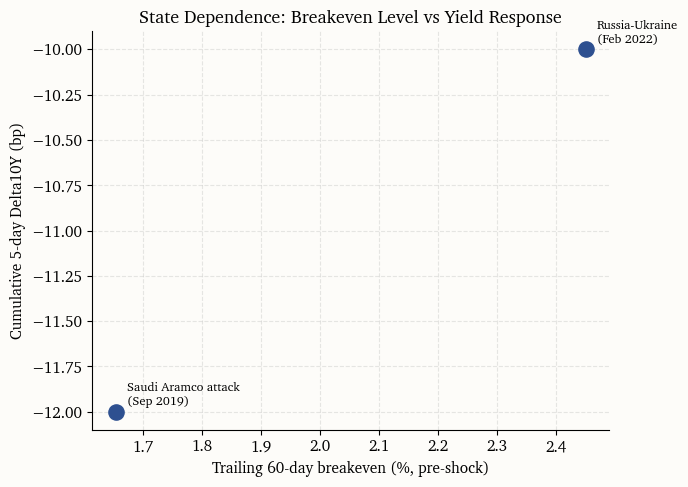

In [26]:
# ---------------------------------------------------------------------------
# State-dependent response: oil-shock episodes comparison
# ---------------------------------------------------------------------------
# Historical oil-shock event dates (approximate onset)
OIL_SHOCK_EVENTS = {
    "Saudi Aramco attack\n(Sep 2019)": pd.Timestamp("2019-09-16"),
    "Russia-Ukraine\n(Feb 2022)": pd.Timestamp("2022-02-24"),
    "Hormuz closure\n(Mar 2026)": EVENT_DATE,
}

# Fetch longer history for comparison episodes
long_start = "2019-01-01"
long_df = fetch_fred_panel(
    ["DGS10", "T10YIE", "THREEFYTP10", "DCOILBRENTEU"],
    start=long_start,
)
long_wide = (
    long_df
    .pivot_table(index="date", columns="series_id", values="value")
    .rename_axis(columns=None)
    .sort_index()
)
long_wide.index = pd.to_datetime(long_wide.index).tz_localize(None)
long_wide = long_wide.ffill()

# Compute rolling 60-day average breakeven as the "credibility state"
long_wide["be_trailing_60"] = long_wide["T10YIE"].rolling(60).mean()

# For each event, compute cumulative 5-day yield response components
EVENT_HORIZON = 5  # trading days
results = []

for label, evt in OIL_SHOCK_EVENTS.items():
    # Find nearest available date
    available = long_wide.index[long_wide.index >= evt]
    if len(available) < EVENT_HORIZON + 1:
        continue
    t0 = available[0]
    t_end_idx = long_wide.index.get_loc(t0) + EVENT_HORIZON
    if t_end_idx >= len(long_wide):
        continue
    t_end = long_wide.index[t_end_idx]

    pre_be = long_wide.loc[:t0, "be_trailing_60"].iloc[-1]
    d_10y = long_wide.loc[t_end, "DGS10"] - long_wide.loc[t0, "DGS10"]
    d_tp = long_wide.loc[t_end, "THREEFYTP10"] - long_wide.loc[t0, "THREEFYTP10"]
    d_be = long_wide.loc[t_end, "T10YIE"] - long_wide.loc[t0, "T10YIE"]
    d_brent = long_wide.loc[t_end, "DCOILBRENTEU"] - long_wide.loc[t0, "DCOILBRENTEU"]

    results.append({
        "event": label,
        "date": evt,
        "pre_shock_be": pre_be,
        "Delta10Y_bp": d_10y * 100,
        "DeltaTP_bp": d_tp * 100,
        "DeltaBE_bp": d_be * 100,
        "DeltaBrent_usd_bbl": d_brent,
    })

events_df = pd.DataFrame(results)
display(events_df.set_index("event"))

# Scatter: pre-shock breakeven vs 5-day yield response
if len(events_df) >= 2:
    fig, ax = plt.subplots(figsize=(7, 5))
    ax.scatter(events_df["pre_shock_be"], events_df["Delta10Y_bp"],
               s=120, color=PALETTE["blue"], zorder=5)
    for _, row in events_df.iterrows():
        ax.annotate(row["event"], (row["pre_shock_be"], row["Delta10Y_bp"]),
                    textcoords="offset points", xytext=(8, 5), fontsize=9)
    ax.set_xlabel("Trailing 60-day breakeven (%, pre-shock)")
    ax.set_ylabel("Cumulative 5-day Delta10Y (bp)")
    ax.set_title("State Dependence: Breakeven Level vs Yield Response")
    plt.tight_layout()
    plt.show()

# Central Bank Stance Index

The quantitative indices developed above measure what markets are doing. This section adds a complementary measure of what policymakers are saying, specifically about supply-shock transmission and second-round inflation risk. The Central Bank Stance Index ($\text{CBS}_t$) is derived from Federal Reserve speeches and FOMC statements using large-language-model extraction.

The pipeline proceeds in three stages. First, the full text of each public speech and statement from the Federal Reserve Board website is scraped for the period January 2025 through the present. Second, each document is chunked into segments of roughly 800 tokens and scored by an LLM along two dimensions: topic relevance (whether the chunk discusses energy, oil, inflation expectations, supply shocks, or look-through language) and policy stance on supply-shock transmission (dovish, neutral, or hawkish). Third, the chunk-level scores are aggregated to a weekly index.

The resulting index does not predict policy. Its value lies in tracking how the Fed's narrative on supply-shock risk evolves, and whether that narrative leads or lags the market-implied repricing observed in the IPRS.

## Scraping Fed speeches and statements

In [37]:
# ---------------------------------------------------------------------------
# Scrape Federal Reserve speeches and FOMC statements
# ---------------------------------------------------------------------------

import time
import xml.etree.ElementTree as ET

SPEECHES_CACHE = CACHE_DIR / "fed_speeches.json"
CB_SCRAPE_START = date(2025, 1, 1)


def scrape_fed_speeches(start_date: date) -> list[dict]:
    """Scrape speech metadata and full text from the Fed RSS feed.

    The speeches page HTML structure changes often, while the official RSS feed
    is stable and provides canonical speech/testimony links and publication
    dates. Each linked page is fetched to recover the full text and speaker.
    """
    feed_url = "https://www.federalreserve.gov/feeds/speeches_and_testimony.xml"
    base = "https://www.federalreserve.gov"
    headers = {"User-Agent": "Mozilla/5.0 (research; academic use)"}

    resp = requests.get(feed_url, headers=headers, timeout=30)
    resp.raise_for_status()
    root = ET.fromstring(resp.content)

    speeches = []
    for item in root.findall("./channel/item"):
        title = (item.findtext("title") or "").strip()
        link = (item.findtext("link") or "").strip()
        pub_date = (item.findtext("pubDate") or "").strip()
        if not link:
            continue
        try:
            speech_date = pd.to_datetime(pub_date).date()
        except Exception:
            continue
        if speech_date < start_date:
            continue

        if not link.startswith("http"):
            link = base + link

        speeches.append({
            "date": speech_date.isoformat(),
            "speaker": "Unknown",
            "title": title,
            "url": link,
            "text": None,
        })

    for sp in speeches:
        try:
            r = requests.get(sp["url"], headers=headers, timeout=30)
            r.raise_for_status()
            page = BeautifulSoup(r.text, "html.parser")
            article = page.select_one("#article, .col-xs-12.col-sm-8.col-md-8, .article")
            if article:
                sp["text"] = article.get_text(separator="\n", strip=True)
            else:
                sp["text"] = page.get_text(separator="\n", strip=True)[:20000]

            speaker_el = page.select_one(".speaker, .article__speaker, h3")
            if speaker_el:
                sp["speaker"] = speaker_el.get_text(strip=True)
            time.sleep(0.25)
        except Exception as exc:
            sp["text"] = f"[Fetch failed: {exc}]"

    return speeches


def scrape_fomc_statements(start_date: date) -> list[dict]:
    """Scrape only canonical FOMC statement pages from the Fed calendar page."""
    base = "https://www.federalreserve.gov"
    cal_url = f"{base}/monetarypolicy/fomccalendars.htm"
    headers = {"User-Agent": "Mozilla/5.0 (research; academic use)"}

    resp = requests.get(cal_url, headers=headers, timeout=30)
    resp.raise_for_status()
    soup = BeautifulSoup(resp.text, "html.parser")

    statements = []
    seen = set()
    canonical_pattern = re.compile(r"/newsevents/pressreleases/monetary(\d{8})a\.htm$")

    for link in soup.select("a[href*='pressreleases/monetary']"):
        href = link.get("href", "")
        if not href:
            continue
        if not href.startswith("http"):
            href = base + href

        match = canonical_pattern.search(href)
        if not match:
            continue
        if href in seen:
            continue
        seen.add(href)

        try:
            stmt_date = datetime.strptime(match.group(1), "%Y%m%d").date()
        except ValueError:
            continue
        if stmt_date < start_date:
            continue

        statements.append({
            "date": stmt_date.isoformat(),
            "speaker": "FOMC",
            "title": f"FOMC Statement {stmt_date.isoformat()}",
            "url": href,
            "text": None,
        })

    for st in statements:
        try:
            r = requests.get(st["url"], headers=headers, timeout=30)
            r.raise_for_status()
            page = BeautifulSoup(r.text, "html.parser")
            article = page.select_one("#article, .col-xs-12.col-sm-8.col-md-8, .article")
            if article:
                st["text"] = article.get_text(separator="\n", strip=True)
            else:
                st["text"] = page.get_text(separator="\n", strip=True)[:20000]
            time.sleep(0.25)
        except Exception as exc:
            st["text"] = f"[Fetch failed: {exc}]"

    return statements


def load_or_refresh_cb_corpus(force_refresh: bool = False, min_docs: int = 10) -> list[dict]:
    if SPEECHES_CACHE.exists() and not force_refresh:
        with open(SPEECHES_CACHE) as f:
            cached = json.load(f)
        if len(cached) >= min_docs:
            print(f"Loaded {len(cached)} documents from cache.")
            return cached
        print(f"Cache only contains {len(cached)} documents; refreshing.")

    speeches = scrape_fed_speeches(CB_SCRAPE_START)
    statements = scrape_fomc_statements(CB_SCRAPE_START)
    corpus = speeches + statements
    corpus.sort(key=lambda x: x["date"])

    with open(SPEECHES_CACHE, "w") as f:
        json.dump(corpus, f, indent=2)

    print(f"Scraped and cached {len(corpus)} documents ({len(speeches)} speeches, {len(statements)} statements).")
    return corpus


cb_corpus = load_or_refresh_cb_corpus(force_refresh=True)

print("\nCorpus summary:")
print(f"  Date range: {cb_corpus[0]['date']} to {cb_corpus[-1]['date']}")
print(f"  Total documents: {len(cb_corpus)}")
print(f"  Speakers sampled: {', '.join(sorted(set(d['speaker'] for d in cb_corpus[:10])))}")

Scraped and cached 25 documents (15 speeches, 10 statements).

Corpus summary:
  Date range: 2025-01-29 to 2026-03-03
  Total documents: 25
  Speakers sampled: FOMC, Regulations, the Supply Side, and Monetary Policy


## LLM stance scoring

In [38]:
# ---------------------------------------------------------------------------
# LLM stance scoring via OpenAI (gpt-4o-mini for cost efficiency)
# Results are cached to a local JSON file so re-renders are free.
# ---------------------------------------------------------------------------
from openai import OpenAI

STANCE_CACHE = CACHE_DIR / "cb_stance_scores.json"

STANCE_PROMPT = textwrap.dedent("""\
    You are an expert monetary policy analyst. Given the following excerpt from
    a Federal Reserve speech or FOMC statement, classify the stance on
    supply-side inflation shocks (specifically oil/energy supply disruptions).

    Return a JSON object with exactly these fields:
    {{
      "topics": ["list of relevant topics from: energy, oil, inflation_expectations,
                   second_round, supply_shock, term_premium, uncertainty, look_through"],
      "stance": "DOVISH" or "NEUTRAL" or "HAWKISH",
      "confidence": "LOW" or "MEDIUM" or "HIGH",
      "key_quote": "most relevant sentence from the text (max 200 chars)"
    }}

    DOVISH means the speaker signals transitory / look-through / accommodation.
    HAWKISH means concern about second-round effects / expectations unanchoring.
    NEUTRAL means balanced or no clear signal on supply shocks.

    If the text does not discuss energy, oil, inflation, or supply shocks at all,
    return stance="NEUTRAL", confidence="LOW", topics=[], key_quote="".

    Text:
    ---
    {chunk}
    ---

    JSON:""")

STANCE_MAP = {"DOVISH": -1, "NEUTRAL": 0, "HAWKISH": 1}


def chunk_text(text: str, max_chars: int = 3000) -> list[str]:
    """Split text into chunks of roughly max_chars, breaking at paragraph boundaries."""
    paragraphs = text.split("\n")
    chunks, current = [], ""
    for para in paragraphs:
        if len(current) + len(para) > max_chars and current:
            chunks.append(current.strip())
            current = ""
        current += para + "\n"
    if current.strip():
        chunks.append(current.strip())
    return chunks


def score_chunk(client: OpenAI, chunk: str) -> dict:
    """Score a single text chunk using gpt-4o-mini."""
    prompt = STANCE_PROMPT.format(chunk=chunk[:4000])
    response = client.chat.completions.create(
        model="gpt-4o-mini",
        messages=[{"role": "user", "content": prompt}],
        temperature=0.0,
        max_tokens=300,
        response_format={"type": "json_object"},
    )
    try:
        return json.loads(response.choices[0].message.content)
    except (json.JSONDecodeError, IndexError):
        return {"topics": [], "stance": "NEUTRAL", "confidence": "LOW", "key_quote": ""}


def score_document(client: OpenAI, doc: dict) -> dict:
    """Score all chunks in a document and return aggregated result."""
    text = doc.get("text", "")
    if not text or text.startswith("[Fetch failed"):
        return {"doc_stance": 0.0, "n_chunks": 0, "n_relevant": 0, "chunks": []}

    chunks = chunk_text(text)
    scored_chunks = []
    for chunk in chunks:
        result = score_chunk(client, chunk)
        result["numeric_stance"] = STANCE_MAP.get(result.get("stance", "NEUTRAL"), 0)
        scored_chunks.append(result)

    conf_weights = {"LOW": 0.25, "MEDIUM": 0.5, "HIGH": 1.0}
    relevant = [c for c in scored_chunks if c.get("topics")]
    if relevant:
        weights = [conf_weights.get(c.get("confidence", "LOW"), 0.25) for c in relevant]
        stances = [c["numeric_stance"] for c in relevant]
        doc_stance = np.average(stances, weights=weights)
    else:
        doc_stance = 0.0

    return {
        "doc_stance": float(doc_stance),
        "n_chunks": len(scored_chunks),
        "n_relevant": len(relevant),
        "chunks": scored_chunks,
    }


def load_cached_scores(expected_docs: int) -> list[dict] | None:
    if not STANCE_CACHE.exists():
        return None
    with open(STANCE_CACHE) as f:
        cached = json.load(f)
    if len(cached) != expected_docs:
        print(f"Stance cache has {len(cached)} docs but corpus has {expected_docs}; refreshing.")
        return None
    print(f"Loaded {len(cached)} scored documents from cache.")
    return cached


stance_results = load_cached_scores(len(cb_corpus))
if stance_results is None:
    client = OpenAI(api_key=OPENAI_API_KEY)
    stance_results = []
    for i, doc in enumerate(cb_corpus):
        print(f"  Scoring {i + 1}/{len(cb_corpus)}: {doc['title'][:60]}...")
        result = score_document(client, doc)
        result["date"] = doc["date"]
        result["speaker"] = doc["speaker"]
        result["title"] = doc["title"]
        stance_results.append(result)

    with open(STANCE_CACHE, "w") as f:
        json.dump(stance_results, f, indent=2, default=str)
    print(f"\nScored and cached {len(stance_results)} documents.")

print(f"Documents scored: {len(stance_results)}")
print(f"Documents with relevant chunks: {sum(1 for r in stance_results if r['n_relevant'] > 0)}")

Stance cache has 35 docs but corpus has 25; refreshing.
  Scoring 1/25: FOMC Statement 2025-01-29...
  Scoring 2/25: FOMC Statement 2025-03-19...
  Scoring 3/25: FOMC Statement 2025-05-07...
  Scoring 4/25: FOMC Statement 2025-06-18...
  Scoring 5/25: FOMC Statement 2025-07-30...
  Scoring 6/25: FOMC Statement 2025-08-22...
  Scoring 7/25: FOMC Statement 2025-09-17...
  Scoring 8/25: FOMC Statement 2025-10-29...
  Scoring 9/25: FOMC Statement 2025-12-10...
  Scoring 10/25: Miran, Regulations, the Supply Side, and Monetary Policy...
  Scoring 11/25: Jefferson, Economic Outlook and Monetary Policy Implementati...
  Scoring 12/25: Bowman, Outlook for the Economy and Monetary Policy...
  Scoring 13/25: FOMC Statement 2026-01-28...
  Scoring 14/25: Bowman, Outlook for the Economy and Monetary Policy...
  Scoring 15/25: Waller, Statement by Governor Christopher J. Waller...
  Scoring 16/25: Cook, Economic Outlook...
  Scoring 17/25: Jefferson, Economic Outlook and Supply-Side (Dis)Inflation 

## Stance index construction and overlay

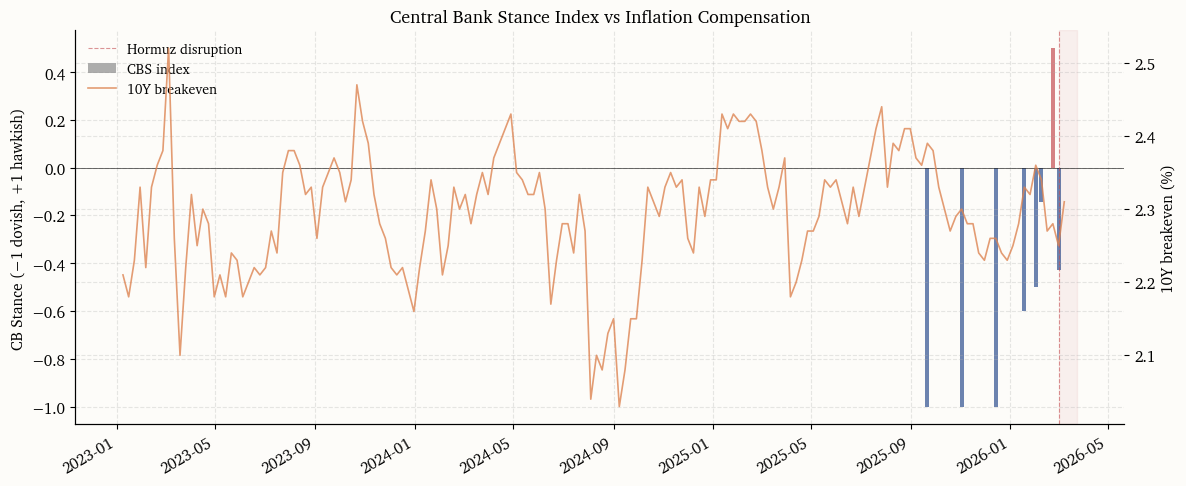

In [41]:
# ---------------------------------------------------------------------------
# Aggregate to weekly Central Bank Stance (CBS) index
# ---------------------------------------------------------------------------
stance_df = pd.DataFrame([
    {"date": pd.Timestamp(r["date"]), "stance": r["doc_stance"], "n_relevant": r["n_relevant"]}
    for r in stance_results
])
stance_df = stance_df.set_index("date").sort_index()

# Weekly aggregation (mean stance, weighted by document relevance)
weekly_stance = (
    stance_df
    .resample("W")
    .apply(lambda g: np.average(g["stance"], weights=np.maximum(g["n_relevant"], 1)) if len(g) > 0 else np.nan)
)
weekly_stance = weekly_stance.dropna()
weekly_stance.name = "CBS"

# Plot: CBS index overlaid with breakeven and policy-path changes
fig, ax1 = plt.subplots(figsize=(12, 5))

# CBS index (bar chart)
colors_bar = [PALETTE["red"] if v > 0 else PALETTE["blue"] if v < 0 else PALETTE["grey"]
              for v in weekly_stance.values]
ax1.bar(weekly_stance.index, weekly_stance.values, width=5, color=colors_bar, alpha=0.7, label="CBS index")
ax1.set_ylabel("CB Stance (−1 dovish, +1 hawkish)")
ax1.axhline(0, color="black", lw=0.4)
_event_shade(ax1)

# Overlay: breakeven (right axis)
ax2 = ax1.twinx()
be_weekly = fred_df["T10YIE"].resample("W").last().dropna()
ax2.plot(be_weekly.index, be_weekly.values, color=PALETTE["orange"], lw=1.2, alpha=0.8, label="10Y breakeven")
ax2.set_ylabel("10Y breakeven (%)")

ax1.set_title("Central Bank Stance Index vs Inflation Compensation")
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

# Event Study

This section brings together the three indices and the yield decomposition in a single event-study window centered on the onset of the Hormuz disruption. The window spans 20 business days before the event through 40 business days after, capturing both the pre-shock baseline and the full initial market response.

The purpose of this consolidated view is to answer the central question posed in the introduction: does the rate market treat the shock as transitory (stable front end, term-premium-driven long end) or does it price second-round inflation risk (breakeven widening, policy-path repricing)?

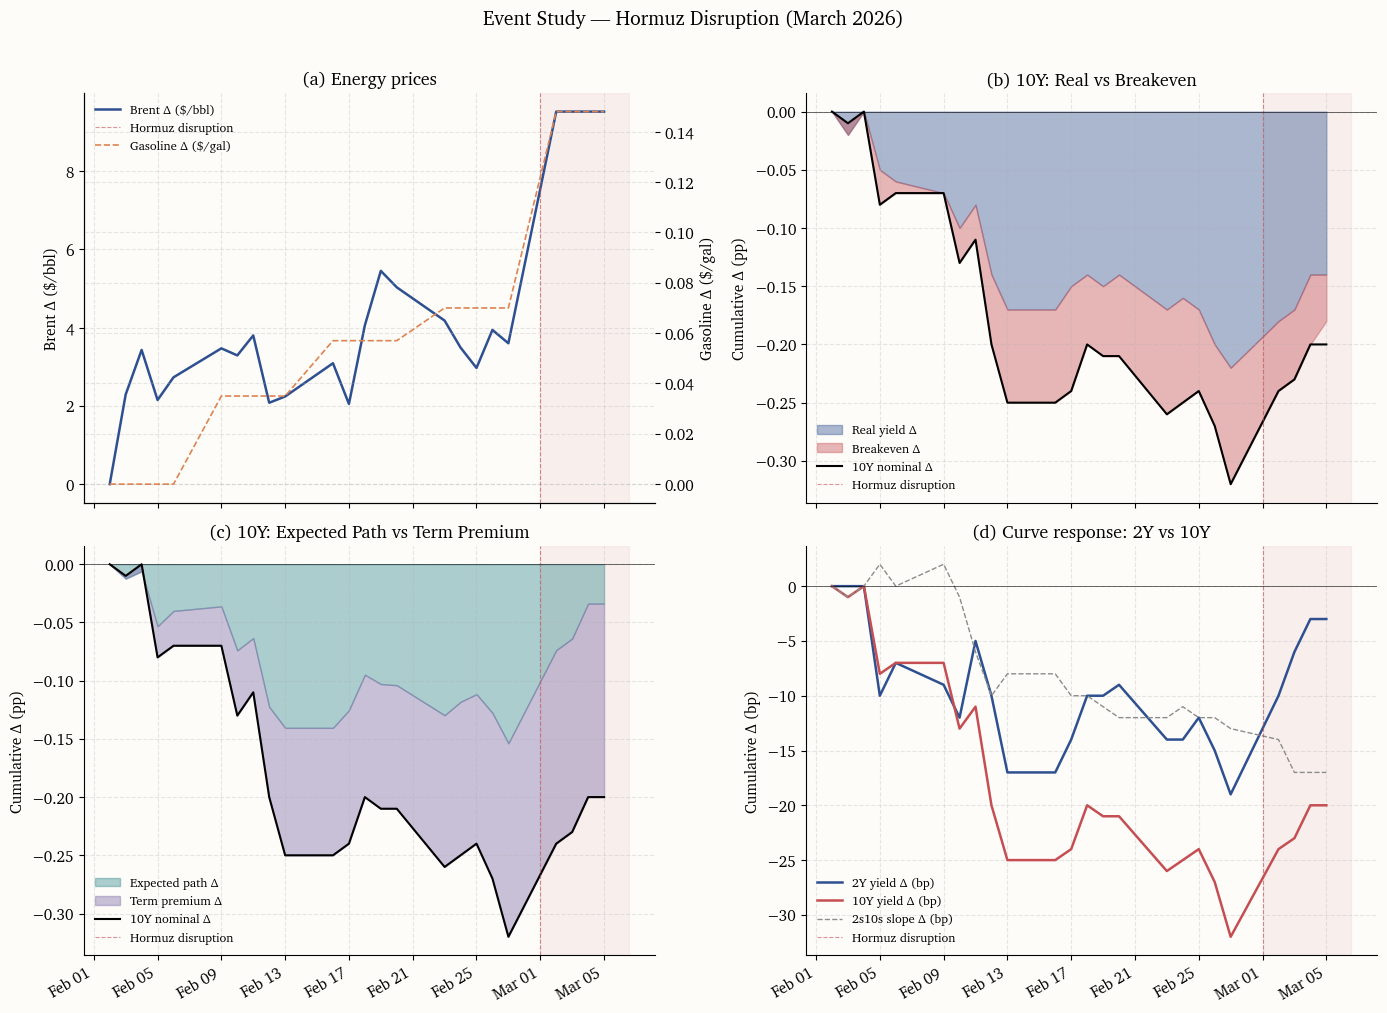

In [34]:
# ---------------------------------------------------------------------------
# Event study: consolidated multi-panel chart
# ---------------------------------------------------------------------------

# Build event-window slice
event_series = fred_df[["DGS10", "DGS2", "DFII10", "T10YIE", "THREEFYTP10",
                         "DCOILBRENTEU", "GASREGW"]].dropna(subset=["DGS10"]).copy()

# Find the reference index position
ref_idx = event_series.index.searchsorted(EVENT_DATE)
window_start = max(ref_idx - EVENT_WINDOW_PRE, 0)
window_end = min(ref_idx + EVENT_WINDOW_POST, len(event_series) - 1)
ew = event_series.iloc[window_start:window_end + 1].copy()

# Cumulative changes from t-1 (day before event window starts using as reference)
ref_vals = ew.iloc[0]
for col in ew.columns:
    ew[f"cum_{col}"] = ew[col] - ref_vals[col]

# Also add the expected-path component
ew["cum_expected_path"] = ew["cum_DGS10"] - ew["cum_THREEFYTP10"]

# Relative trading day index (0 = event onset)
event_loc = ew.index.searchsorted(EVENT_DATE)
ew["t"] = np.arange(len(ew)) - event_loc

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# ── Panel A: Crude oil & gasoline ──
ax = axes[0, 0]
ax.plot(ew.index, ew["cum_DCOILBRENTEU"], color=PALETTE["blue"], lw=1.8, label="Brent Δ ($/bbl)")
ax2 = ax.twinx()
ax2.plot(ew.index, ew["cum_GASREGW"], color=PALETTE["orange"], lw=1.2, ls="--", label="Gasoline Δ ($/gal)")
ax2.set_ylabel("Gasoline Δ ($/gal)")
_event_shade(ax)
ax.set_ylabel("Brent Δ ($/bbl)")
ax.set_title("(a) Energy prices")
lines_a = ax.get_legend_handles_labels()
lines_b = ax2.get_legend_handles_labels()
ax.legend(lines_a[0] + lines_b[0], lines_a[1] + lines_b[1], loc="upper left", fontsize=9)

# ── Panel B: Nominal = Real + Breakeven ──
ax = axes[0, 1]
ax.fill_between(ew.index, 0, ew["cum_DFII10"], alpha=0.4, color=PALETTE["blue"], label="Real yield Δ")
ax.fill_between(ew.index, ew["cum_DFII10"], ew["cum_DFII10"] + ew["cum_T10YIE"],
                alpha=0.4, color=PALETTE["red"], label="Breakeven Δ")
ax.plot(ew.index, ew["cum_DGS10"], color="black", lw=1.5, label="10Y nominal Δ")
_event_shade(ax)
ax.axhline(0, color="black", lw=0.4)
ax.set_ylabel("Cumulative Δ (pp)")
ax.set_title("(b) 10Y: Real vs Breakeven")
ax.legend(loc="best", fontsize=9)

# ── Panel C: Expected path vs Term premium ──
ax = axes[1, 0]
ax.fill_between(ew.index, 0, ew["cum_expected_path"], alpha=0.4, color=PALETTE["teal"], label="Expected path Δ")
ax.fill_between(ew.index, ew["cum_expected_path"],
                ew["cum_expected_path"] + ew["cum_THREEFYTP10"],
                alpha=0.4, color=PALETTE["purple"], label="Term premium Δ")
ax.plot(ew.index, ew["cum_DGS10"], color="black", lw=1.5, label="10Y nominal Δ")
_event_shade(ax)
ax.axhline(0, color="black", lw=0.4)
ax.set_ylabel("Cumulative Δ (pp)")
ax.set_title("(c) 10Y: Expected Path vs Term Premium")
ax.legend(loc="best", fontsize=9)

# ── Panel D: Front end (2Y) vs back end (10Y) ──
ax = axes[1, 1]
ax.plot(ew.index, ew["cum_DGS2"] * 100, color=PALETTE["blue"], lw=1.8, label="2Y yield Δ (bp)")
ax.plot(ew.index, ew["cum_DGS10"] * 100, color=PALETTE["red"], lw=1.8, label="10Y yield Δ (bp)")
ax.plot(ew.index, (ew["cum_DGS10"] - ew["cum_DGS2"]) * 100, color=PALETTE["grey"],
        lw=1, ls="--", label="2s10s slope Δ (bp)")
_event_shade(ax)
ax.axhline(0, color="black", lw=0.4)
ax.set_ylabel("Cumulative Δ (bp)")
ax.set_title("(d) Curve response: 2Y vs 10Y")
ax.legend(loc="best", fontsize=9)

for ax in axes.flat:
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))

fig.suptitle("Event Study — Hormuz Disruption (March 2026)", fontsize=14, y=1.01)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

# Conclusion

The analysis above traces the March 2026 Hormuz disruption from the physical chokepoint through delivered-energy costs and into the term structure of interest rates. Three scenarios frame the interpretation.

The first scenario, transitory look-through, holds if the front end of the curve remains stable, breakevens widen only modestly, and the bulk of the long-end yield move is absorbed by the Kim–Wright term premium. Under this reading, the market expects central banks to look through the energy price spike, and the yield-curve reaction is dominated by uncertainty pricing rather than policy-path repricing.

The second scenario, second-round risk, applies if breakevens widen persistently and the two-year yield (or SOFR-implied forwards) moves significantly higher. This pattern would indicate that the market expects the inflation impulse to feed through to broader price pressures, forcing a tighter policy path even as the supply shock itself may be temporary.

The third scenario, term-premium shock, describes a situation where both the expected-path and term-premium components move, but the term premium accounts for a disproportionate share. This would suggest that the market is not so much repricing the policy path as demanding additional compensation for the elevated tail risk of a sustained inflation regime shift.

The data needed to adjudicate among these scenarios are, for the most part, available in real time. The IPRS decomposition presented here can be updated daily. The Central Bank Stance Index, refreshed as new speeches and statements are published, provides a leading indicator of whether the Fed's rhetoric is shifting from look-through language toward second-round concern. A decisive shift in the CBS index, particularly if accompanied by widening breakevens and front-end repricing, would be the clearest signal that the transitory interpretation has broken down.